##### Copyright 2025 Google LLC.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Image understanding

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemma/docs/capabilities/vision/image"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on ai.google.dev</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/docs/capabilities/vision/image.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/google-gemma/cookbook/blob/main/docs/capabilities/vision/image.ipynb"><img src="https://www.kaggle.com/static/images/logos/kaggle-logo-transparent-300.png" height="32" width="70"/>Run in Kaggle</a>
  </td>
  <td>
    <a target="_blank" href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fgoogle-gemma%2Fcookbook%2Fmain%2Fdocs%2Fcapabilities%2Fvision%2Fimage.ipynb"><img src="https://ai.google.dev/images/cloud-icon.svg" width="40" />Open in Vertex AI</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google-gemma/cookbook/blob/main/docs/capabilities/vision/image.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

You can use Gemma 3 and later models to analyze and understand the content of images. This capability includes tasks like describing image content, identifying objects, recognizing scenes, and even inferring the context from visual information.

Here are some examples demonstrating these capabilities.

This notebook will run on T4 GPU.

## Install Python packages

Install the Hugging Face libraries required for running the Gemma model and making requests.

In [ ]:
# Install PyTorch & other libraries
!pip install torch accelerate

# Install the transformers library
!pip install "transformers>=5.5.0"

## Load Model

Use `transformers` library to load the pipeline

In [3]:
MODEL_ID = "google/gemma-4-E2B-it" # @param ["google/gemma-4-E2B-it","google/gemma-4-E4B-it", "google/gemma-4-31B-it", "google/gemma-4-26B-A4B-it"]

from transformers import pipeline

vqa_pipe = pipeline(
    task="image-text-to-text",
    model=MODEL_ID,
    device_map="auto",
    dtype="auto"
)

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

## Use a prompt template

The following example shows how to provide an image and ask question about it.

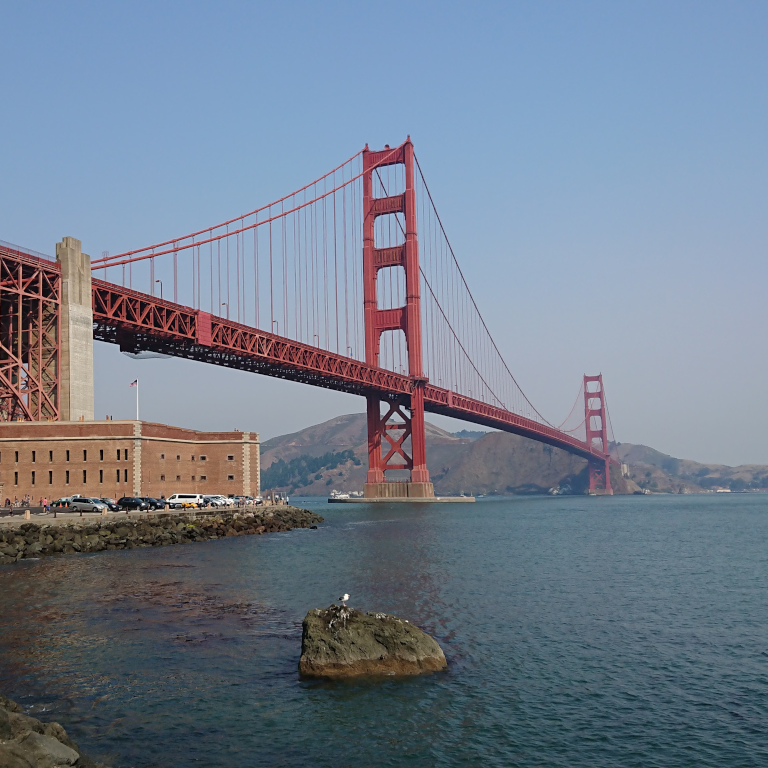

This image shows the **Golden Gate Bridge** in San Francisco, California.

Key elements visible in the picture include:

* **The Golden Gate Bridge:** The iconic red suspension bridge spanning a body of water.
* **The Water:** A large expanse of water (likely the San Francisco Bay or the Pacific Ocean).
* **A Rocky Outcrop/Island:** In the foreground, there is a dark, rocky formation or small island in the water with a white bird perched on it.
* **Hills/Landmass:** In the background, there are hills or mountains on the far shore.
* **Clear Sky:** The sky is clear and bright blue, suggesting fair weather.

It's a scenic photograph capturing the bridge and the coastal environment.<turn|>


In [4]:
from PIL import Image
from IPython.display import display
import requests

from transformers import GenerationConfig
config = GenerationConfig.from_pretrained(MODEL_ID)
config.max_new_tokens = 512
gen_kwargs = dict(generation_config=config)

img_url = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/GoldenGate.png"
input_image = Image.open(requests.get(img_url, stream=True).raw)
display(input_image)

messages = [
    {
        "role": "user", "content": [
            {"type": "image", "url": img_url},
            {"type": "text", "text": "What is shown in this image?"}
        ]
    }
]

output = vqa_pipe(messages, return_full_text=False, generate_kwargs=gen_kwargs)
print(output[0]['generated_text'])

## Prompting with multiple images

You can provide multiple images in a single prompt by including multiple image content in prompt template.

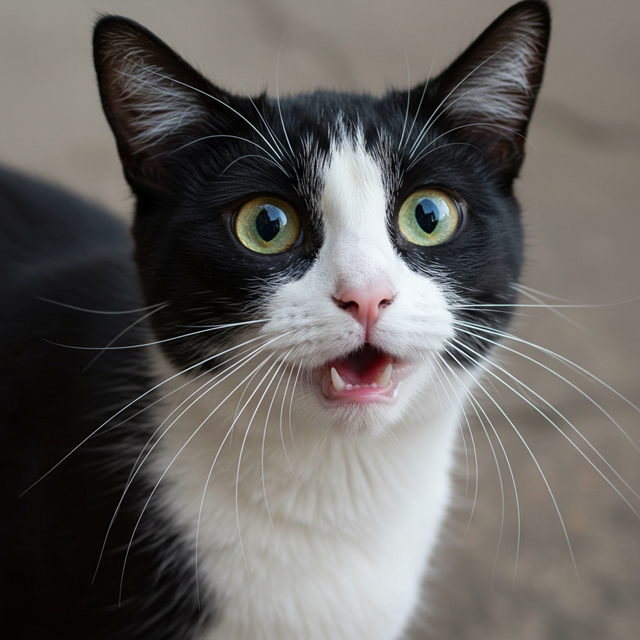

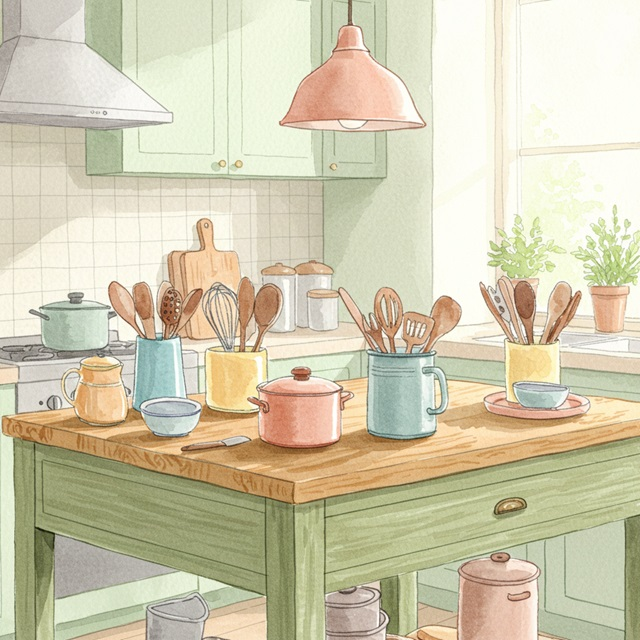

Here are captions for the two images you provided:

**Image 1: Black and White Cat**

**Short & Sweet:**
* Pure elegance.
* Mischief in black and white.
* Those emerald eyes.
* A portrait of feline charm.

**Descriptive & Engaging:**
* The captivating gaze of a beautiful tuxedo cat.
* Alert, curious, and utterly stunning.
* When your cat has that perfectly intense expression.
* Black, white, and mesmerizing green eyes.

**Funny/Playful:**
* Plotting world domination, one glance at a time.
* Judging your life choices.
* Warning: May cause extreme cuteness overload.

**Hashtags:**
`#BlackCat #TuxedoCat #CatLover #FelineFriends #GreenEyes #PetPortrait #CatsofInstagram #CuteCat`

***

**Image 2: Kitchen Scene with Wooden Table**

**Short & Sweet:**
* Kitchen vibes.
* Morning prep.
* Rustic kitchen charm.
* Baking dreams.

**Descriptive & Engaging:**
* A cozy, bright kitchen setup ready for culinary adventures.
* Wooden countertops and colorful accents make for the perfect workspace.
* Gath

In [5]:
from PIL import Image
from IPython.display import display
import requests

from transformers import GenerationConfig
config = GenerationConfig.from_pretrained(MODEL_ID)
config.max_new_tokens = 512
gen_kwargs = dict(generation_config=config)

img_urls = [
    "https://ai.google.dev/gemma/docs/capabilities/vision/images/surprise.png",
    "https://ai.google.dev/gemma/docs/capabilities/vision/images/kitchen.jpg",
]
for img in img_urls:
    display(Image.open(requests.get(img, stream=True).raw))

messages = [
    {
        "role": "user", "content": [
            {"type": "image", "url": img_urls[0]},
            {"type": "image", "url": img_urls[1]},
            {"type": "text", "text": "Caption these images."}
        ]
    }
]

output = vqa_pipe(messages, return_full_text=False, generate_kwargs=gen_kwargs)
print(output[0]['generated_text'])

##  OCR (Optical Character Recognition)

Models can recognize multilingual texts in the image.

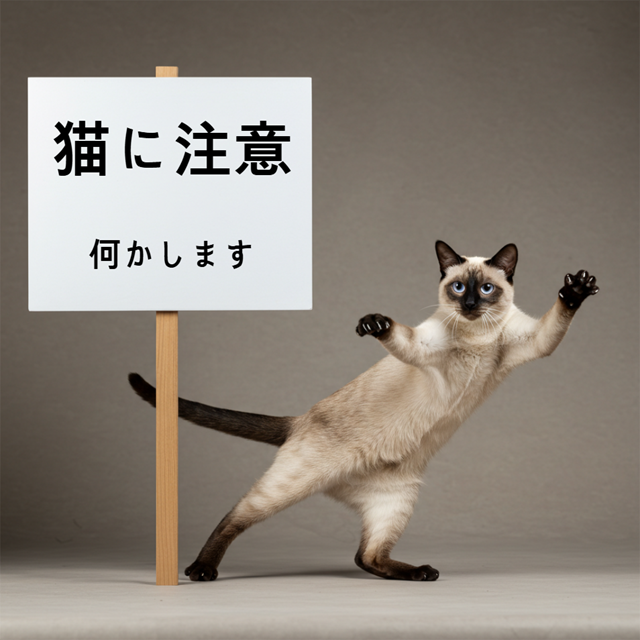

The sign in the image says:

**猫に注意** (Neko ni chūi) - which means **"Caution: Cat"** or **"Beware of cats"**.

Below that, it says:

**何かします** (Nanika shimasu) - which means **"I will do something"** or **"I will do something about it"**.

In the context of the picture (showing a cat playfully jumping), the sign is likely humorous or a lighthearted warning.<turn|>


In [6]:
from PIL import Image
from IPython.display import display
import requests

from transformers import GenerationConfig
config = GenerationConfig.from_pretrained(MODEL_ID)
config.max_new_tokens = 512
gen_kwargs = dict(generation_config=config)

img_url = "https://ai.google.dev/gemma/docs/capabilities/vision/images/cat.png"
input_image = Image.open(requests.get(img_url, stream=True).raw)
display(input_image)

messages = [
    {
        "role": "user", "content": [
            {"type": "image", "url": img_url},
            {"type": "text", "text": "What does the sign say?"}
        ]
    }
]

output = vqa_pipe(messages, return_full_text=False, generate_kwargs=gen_kwargs)
print(output[0]['generated_text'])

## Object Detection

Models are trained to detect objects in an image and get their bounding box coordinates. Bounding box coordinates are expressed as normalized values relative to a 1000x1000 grid. You need to descale these coordinates based on your original image size.

```json
[
  {"box_2d": [243, 252, 956, 415], "label": "person"},
  {"box_2d": [356, 606, 654, 802], "label": "cat"}
]
```<turn|>


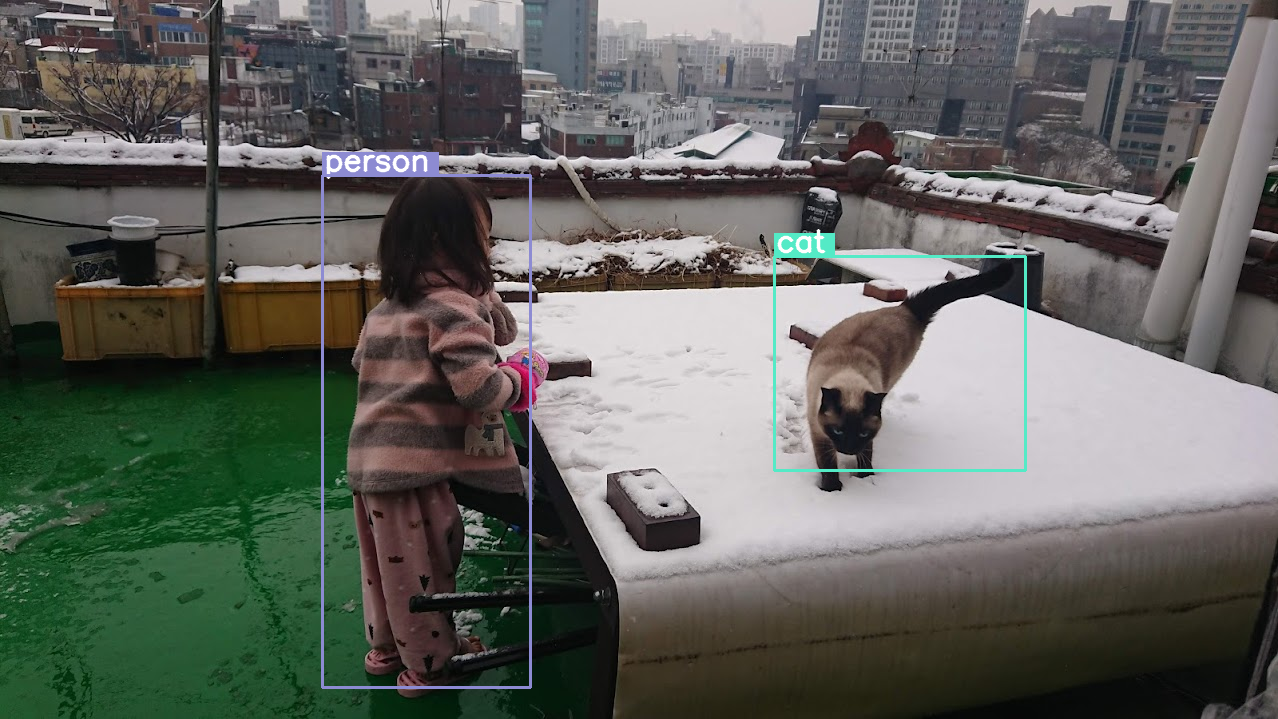

In [7]:
import numpy as np
from PIL import Image
from IPython.display import display
import requests

import cv2
import re, json

from transformers import GenerationConfig
config = GenerationConfig.from_pretrained(MODEL_ID)
config.max_new_tokens = 512
gen_kwargs = dict(generation_config=config)

# Load Image
img_url = "https://raw.githubusercontent.com/bebechien/gemma/refs/heads/main/PaliGemma_Demo.JPG"
input_image = Image.open(requests.get(img_url, stream=True).raw)

###############################
# some helper functions below #
###############################

def draw_bounding_box(image, coordinates, label, label_colors, width, height):
    y1, x1, y2, x2 = [int(coord)/1000 for coord in coordinates]
    y1, x1, y2, x2 = map(round, (y1*height, x1*width, y2*height, x2*width))

    text_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1, 3)
    text_width, text_height = text_size

    text_x = x1 + 2
    text_y = y1 - 5

    font_scale = 1
    label_rect_width = text_width + 8
    label_rect_height = int(text_height * font_scale)

    color = label_colors.get(label, None)
    if color is None:
        color = np.random.randint(0, 256, (3,)).tolist()
        label_colors[label] = color

    cv2.rectangle(image, (x1, y1 - label_rect_height), (x1 + label_rect_width, y1), color, -1)

    thickness = 2
    cv2.putText(image, label, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
    return image

def draw_results(text_content):
  match = re.search(r'```json\s+(.*?)\s+```', text_content, re.DOTALL)
  if match:
    json_string = match.group(1)
    # Parse the string into a Python list/object
    data_list = json.loads(json_string)

    labels = []
    label_colors = {}
    output_image = input_image
    output_img = np.array(input_image)

    for item in data_list:
      width = input_image.size[0]
      height = input_image.size[1]

      # Draw bounding boxes on the frame.
      image = cv2.cvtColor(np.array(input_image), cv2.COLOR_RGB2BGR)
      output_img = draw_bounding_box(output_img, item["box_2d"], item["label"], label_colors, width, height)

      output_image = Image.fromarray(output_img)

    return output_image
  else:
    print("No JSON code block found.")



messages = [
    {
        "role": "user", "content": [
            {"type": "image", "url": img_url},
            {"type": "text", "text": "detect person and cat"}
        ]
    }
]

output = vqa_pipe(messages, return_full_text=False, generate_kwargs=gen_kwargs)
print(output[0]['generated_text'])

draw_results(output[0]['generated_text'])


## Variable Resolution (Token Budget)

All Gemma 4 models support variable resolution which means that images of different resolutions can be processed. Moreover, you can decide if you want to process a given image in a higher or lower resolution. If you are performing object detection, for instance, you might want to process the image in a higher resolution. Video understanding, for instance, can be done with a lower resolution for each frame to speed up inference. Essentially, it is a tradeoff between inference speed and accuracy of the image representations.

This choice is controlled by the token budget, which represents the maximum number of visual tokens (also called **visual token embeddings**) that are generated for a given image.

The user can decide between budget sizes of 70, 140, 280, 560, or 1120 tokens. Depending on the budget, the input is resized. If you have a higher budget (like 1120 tokens), then your image can maintain a higher resolution and as a result will have many more patches to process. If you have a lower budget (like 70 tokens), then your image needs to be downscaled and you will have fewer patches that need to be processed. With a higher budget (and therefore more tokens), you can capture much more information than with a lower budget.


This budget determines how much the image is resized. Imagine you have a budget of 280 tokens, then the maximum number of patches will be 9 x 280 = 2,520. Why times 9? That’s because in the next step, every 3x3 block of neighboring patches are merged into a single embedding by averaging them. The resulting embeddings are the visual token embeddings. The more **visual token embeddings** we have, the more fine-grained information can be extracted from an image.

Let's explore what happens if we perform object detection on an image and setting the budget size very low (70):

```json
[
  {"box_2d": [454, 871, 533, 923], "label": "person"},
  {"box_2d": [551, 316, 665, 628], "label": "car"}
]
```<turn|>


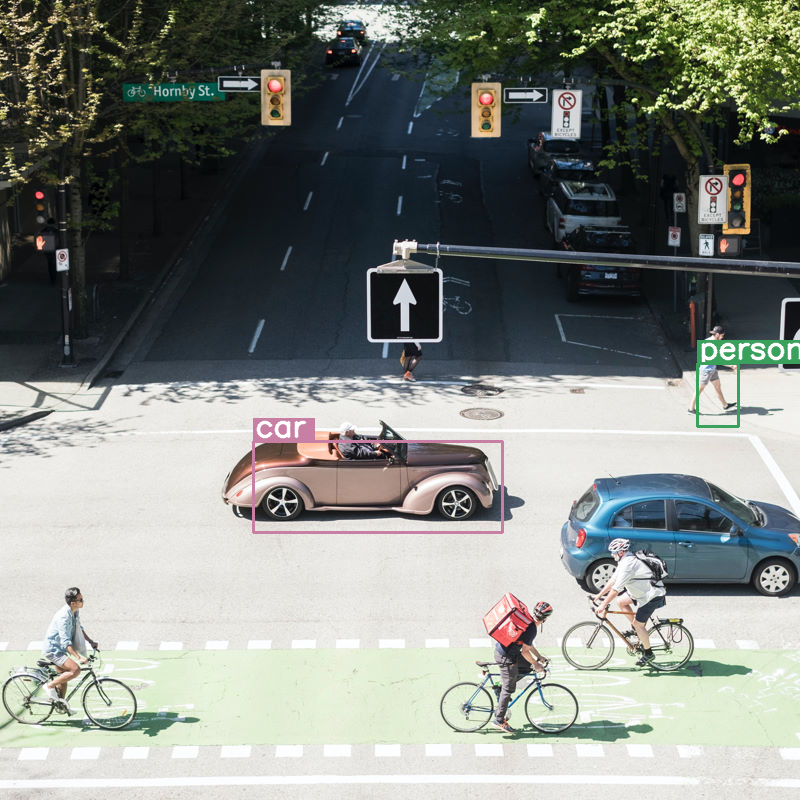

In [8]:
import numpy as np
from PIL import Image
import requests, cv2, re, json

from transformers import GenerationConfig
config = GenerationConfig.from_pretrained(MODEL_ID)
config.max_new_tokens = 512
gen_kwargs = dict(generation_config=config)

img_url = "https://huggingface.co/datasets/Xenova/transformers.js-docs/resolve/main/city-streets.jpg"
input_image = Image.open(requests.get(img_url, stream=True).raw)

def draw_bounding_box(image, coordinates, label, label_colors, width, height):
    """Draw a bounding box based on input image and coordinates"""
    y1, x1, y2, x2 = [int(c) / 1000 for c in coordinates]
    y1, x1, y2, x2 = round(y1 * height), round(x1 * width), round(y2 * height), round(x2 * width)

    color = label_colors.setdefault(label, np.random.randint(0, 256, (3,)).tolist())
    text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1, 3)[0]

    cv2.rectangle(image, (x1, y1 - text_size[1]), (x1 + text_size[0] + 8, y1), color, -1)
    cv2.putText(image, label, (x1 + 2, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
    return image

def draw_results(text_content):
    """Based on an input image, draw bounding boxes and labels"""
    # Extract JSON
    match = re.search(r'```json\s+(.*?)\s+```', text_content, re.DOTALL)
    if not match:
        print("No JSON code block found.")
        return None

    # Extract data
    data_list = json.loads(match.group(1))
    output_img = np.array(input_image)
    label_colors = {}
    w, h = input_image.size

    # Draw bounding boxes
    for item in data_list:
        output_img = draw_bounding_box(output_img, item["box_2d"], item["label"], label_colors, w, h)

    return Image.fromarray(output_img)


# Detect person, card, and traffic light
messages = [
    {
        "role": "user", "content": [
            {"type": "image", "url": img_url},
             {"type": "text", "text": "detect person and car, output only ```json"}
        ]
     }
]

# Run pipeline and set token budget to 70
vqa_pipe.image_processor.max_soft_tokens = 70
output = vqa_pipe(messages, return_full_text=False, generate_kwargs=gen_kwargs)
print(output[0]['generated_text'])
draw_results(output[0]['generated_text'])

It does alright but it is clear that the image is being compressed quite a bit as it does not detect all cars and persons. A higher token budget should resolve this!

### Compare Token Budgets

Let's explore what happens when we increase the budget sizes! A larger budget size results in more soft tokens being generated and processed. This should improve the object detection.

Budget Size: 70
# of Image Tokens: 64


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


```json
[
  {"box_2d": [423, 864, 534, 935], "label": "person"},
  {"box_2d": [554, 323, 667, 625], "label": "car"}
]
```<turn|>
Budget Size: 140
# of Image Tokens: 121
```json
[
  {"box_2d": [498, 314, 645, 628], "label": "car"},
  {"box_2d": [753, 554, 917, 716], "label": "person"},
  {"box_2d": [741, 0, 914, 165], "label": "person"},
  {"box_2d": [602, 700, 745, 1000], "label": "car"},
  {"box_2d": [413, 877, 515, 922], "label": "person"}
]
```<turn|>
Budget Size: 280
# of Image Tokens: 256
```json
[
  {"box_2d": [526, 311, 655, 625], "label": "car"},
  {"box_2d": [601, 702, 752, 1000], "label": "car"},
  {"box_2d": [742, 725, 853, 833], "label": "person"},
  {"box_2d": [747, 556, 914, 653], "label": "person"},
  {"box_2d": [743, 5, 906, 155], "label": "person"},
  {"box_2d": [406, 864, 515, 916], "label": "person"}
]
```<turn|>
Budget Size: 560
# of Image Tokens: 529
```json
[
  {"box_2d": [533, 263, 656, 634], "label": "car"},
  {"box_2d": [742, 0, 908, 153], "label": "person"},
 

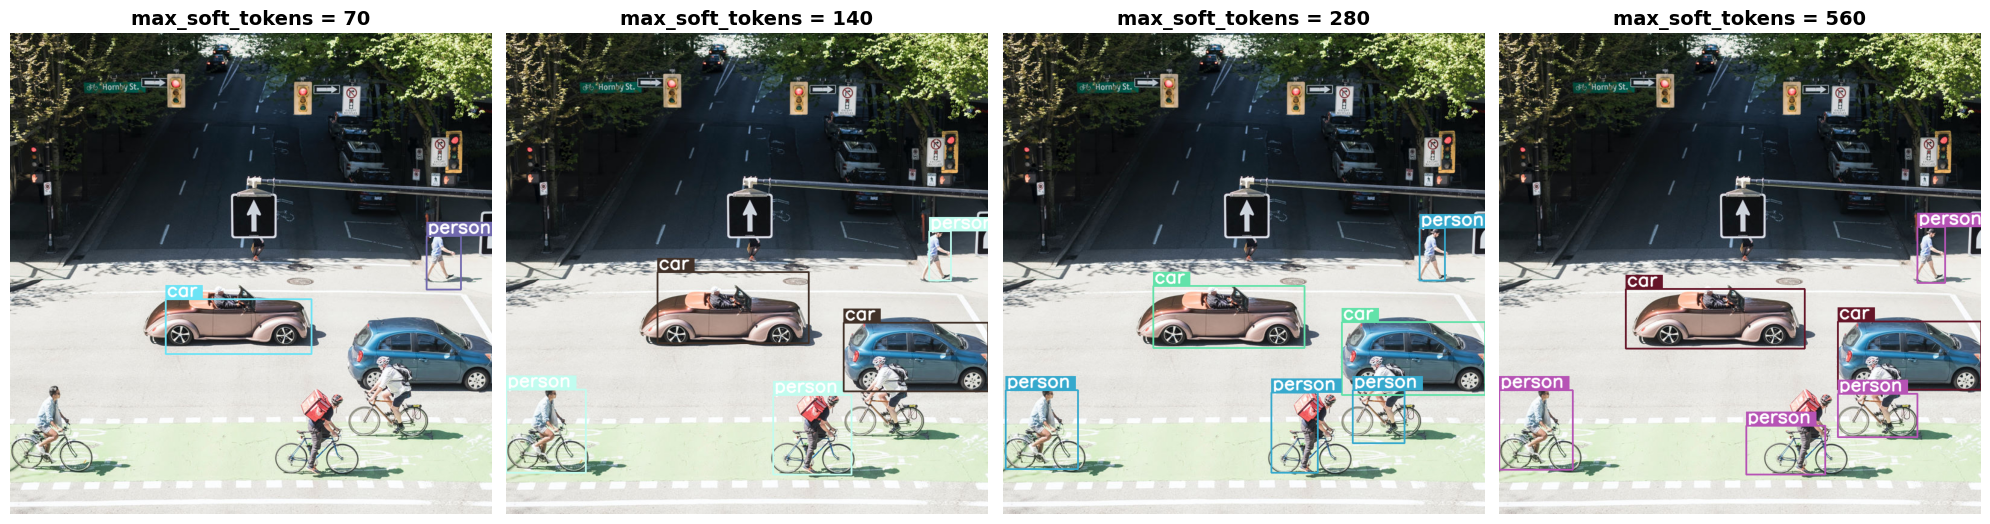

In [10]:
import matplotlib.pyplot as plt

def count_tokens(processor, tokens):
    input_ids = tokens['input_ids'][0]  # Get input IDs from the tokenizer output

    img_counting = []
    img_count = 0

    aud_counting = []
    aud_count = 0

    for x in input_ids:  # Iterate over the token list
        # Use tokenizer.decode() to convert tokens back to words
        word = processor.decode([x])  # No need to convert to JAX array for decoding

        if x == processor.tokenizer.image_token_id:
            img_count = img_count + 1
        elif x == processor.tokenizer.audio_token_id:
            aud_count = aud_count + 1
        elif x == processor.tokenizer.eoi_token_id:
            img_counting.append(img_count)
            img_count = 0
        elif x == processor.tokenizer.eoa_token_id:
            aud_counting.append(aud_count)
            aud_count = 0

    for item in img_counting:
        print(f"# of Image Tokens: {item}")

    for item in aud_counting:
        print(f"# of Audio Tokens: {item}")

input_image.resize((2000, 2000))

# Detect person and car
messages = [
    {
        "role": "user", "content": [
            {"type": "image", "url": img_url},
             {"type": "text", "text": "detect person and car, output only ```json"}
        ]
     }
]


# Run for different budget sizes
budget_sizes = [70, 140, 280, 560]
# 1120 won't fit on T4, but works on L4 or highger
#budget_sizes = [70, 140, 280, 560, 1120]
results = {}

for budget in budget_sizes:
    print(f"Budget Size: {budget}")
    vqa_pipe.image_processor.max_soft_tokens = budget

    inputs = vqa_pipe.processor.apply_chat_template(messages, tokenize=True, return_dict=True, return_tensors="pt")
    count_tokens(vqa_pipe.processor, inputs)

    output = vqa_pipe(messages, return_full_text=False, generate_kwargs=gen_kwargs)
    result_text = output[0]['generated_text']
    print(output[0]['generated_text'])
    result_image = draw_results(result_text)
    if result_image:
        results[budget] = result_image

# Display side-by-side
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 6))
if len(results) == 1:
    axes = [axes]

for ax, (budget, img) in zip(axes, results.items()):
    ax.imshow(img)
    ax.set_title(f"max_soft_tokens = {budget}", fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Summary and next steps

In this guide, you learned how to use Gemma 4 models for image understanding tasks. The examples covered generating text from images, using prompt templates for visual QA, processing multiple images simultaneously, optical character recognition (OCR), object detection with bounding boxes, and managing variable resolutions using token budgets.

Check out other resources.

- [Prompt and system instructions](https://ai.google.dev/gemma/docs/core/prompt-formatting-gemma4)
- [Function calling](https://ai.google.dev/gemma/docs/capabilities/text/function-calling-gemma4)
- [Run Gemma overview](https://ai.google.dev/gemma/docs/run)